Practice 7

7. Add one more day to the Play Tennis table (notebook 4) with weather and label of your choice, refit, and re-plot. Did the tree structure change?

Cell 1

In [1]:
# Import required libraries before using them.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


Cell 2

In [2]:
# A dataset contains features and target labels.

tennis = pd.DataFrame({
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain","Overcast", "Sunny","Overcast", "Rain"],

    "Humidity": ["High", "High", "High","High", "Normal", "Normal","Normal", "Normal","Normal", "High"],

    "Wind": ["Weak", "Strong", "Weak","Weak", "Weak", "Strong","Strong", "Weak","Weak", "Strong"],

    "Play": ["No", "No", "Yes","Yes", "Yes", "No","Yes", "Yes","Yes", "No"]})

Cell 3

In [3]:
# New observations can be added to the dataset.

new_day = pd.DataFrame({"Outlook": ["Sunny"],"Humidity": ["Normal"],"Wind": ["Strong"],"Play": ["Yes"]})

Cell 4

In [4]:
# Combine old data and new data into one dataset.

tennis = pd.concat([tennis, new_day], ignore_index=True)

tennis

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
7,Sunny,Normal,Weak,Yes
8,Overcast,Normal,Weak,Yes
9,Rain,High,Strong,No


Cell 5

In [5]:
# Machine learning models need numerical input.

X_tennis = pd.get_dummies(tennis.drop(columns="Play"))

y_tennis = (tennis["Play"] == "Yes").astype(int)

Cell 6

In [6]:
# Check the transformed features before training.

X_tennis.head()

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,False,False,True,True,False,False,True
1,False,False,True,True,False,True,False
2,True,False,False,True,False,False,True
3,False,True,False,True,False,False,True
4,False,True,False,False,True,False,True


Cell 7

In [7]:
# Model parameters are chosen before training.

tree = DecisionTreeClassifier(max_depth=3,random_state=42)

Cell 8

In [8]:
# Fit means learning patterns from data.

tree.fit(X_tennis,y_tennis)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Cell 9

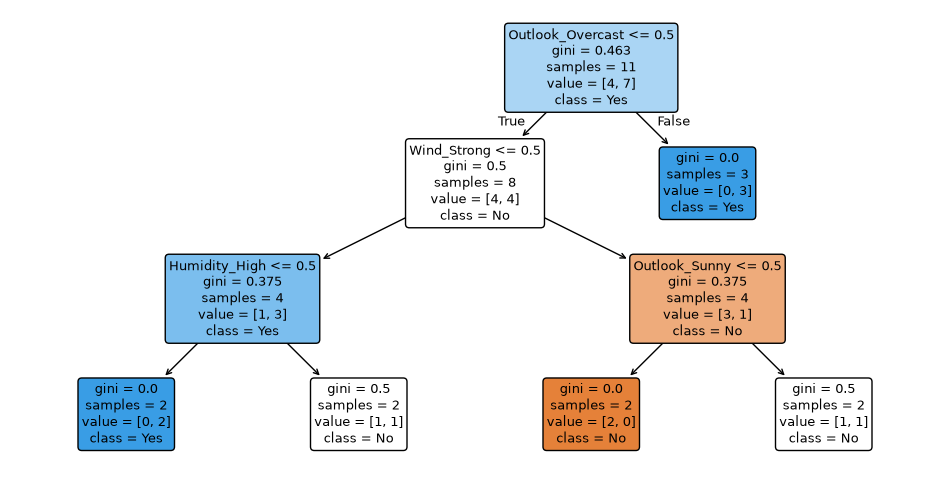

In [9]:
# Plot the trained Decision Tree.

fig, ax = plt.subplots(figsize=(12, 6))

plot_tree(tree,feature_names=X_tennis.columns,class_names=
          ["No", "Yes"],filled=True,rounded=True,fontsize=9,ax=ax)

plt.show()